In [5]:
# File(S) Upload

from google.colab import files
print("Upload CrSb.bands.up.gnu and CrSb.bands.dn.gnu")
uploaded = files.upload()

Upload CrSb.bands.up.gnu and CrSb.bands.dn.gnu


Saving CrSb.bands.dn.gnu to CrSb.bands.dn (1).gnu
Saving CrSb.bands.up.gnu to CrSb.bands.up (1).gnu


In [6]:
# Config

import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

FERMI       = 10.5605
ELIM        = [-1.5, 1]
DPI         = 200

if os.path.exists("CrSb.bands.up.gnu"):
    BANDS_UP_GNU = "CrSb.bands.up.gnu"
    BANDS_DN_GNU = "CrSb.bands.dn.gnu"
elif os.path.exists("CrSb_bands_up.gnu"):
    BANDS_UP_GNU = "CrSb_bands_up.gnu"
    BANDS_DN_GNU = "CrSb_bands_dn.gnu"
else:
    raise FileNotFoundError(
        "Could not find band files. Expected either:\n"
        "  CrSb.bands.up.gnu / CrSb.bands.dn.gnu  (QE default)\n"
        "  CrSb_bands_up.gnu / CrSb_bands_dn.gnu   (renamed)")
print(f"Using: {BANDS_UP_GNU}, {BANDS_DN_GNU}")

K_GAMMA_IDX = 150
K_LABELS    = [r'L$_1$', r'$\Gamma$', r'L$_2$']

N_ARROWS_SINGLE   = 5
N_ARROWS_COMBINED = 4
ARROW_LEN         = 0.08
ARROW_HEAD_W      = 0.4
ARROW_HEAD_L      = 0.25
ARROW_LW          = 1.8

COLOR_UP       = 'red'
COLOR_DN       = 'blue'
COLOR_ARROW_UP = 'darkred'
COLOR_ARROW_DN = 'darkblue'

Using: CrSb.bands.up.gnu, CrSb.bands.dn.gnu


In [7]:
# Parsing

def parse_gnu(fname):
    bands = []
    current = []
    with open(fname) as f:
        for line in f:
            s = line.strip()
            if s == '':
                if current:
                    bands.append(np.array(current))
                    current = []
            else:
                v = s.split()
                current.append([float(v[0]), float(v[1])])
    if current:
        bands.append(np.array(current))
    return bands

def get_visible_bands(bands, fermi, elim):
    visible = []
    for b in bands:
        e = b[:, 1] - fermi
        if e.max() > elim[0] and e.min() < elim[1]:
            visible.append((b[:, 0], e))
    return visible

bands_up = parse_gnu(BANDS_UP_GNU)
bands_dn = parse_gnu(BANDS_DN_GNU)

k = bands_up[0][:, 0]
k_gamma = k[K_GAMMA_IDX]
k_max   = k[-1]

vis_up = get_visible_bands(bands_up, FERMI, ELIM)
vis_dn = get_visible_bands(bands_dn, FERMI, ELIM)

print(f"Total bands: {len(bands_up)} up, {len(bands_dn)} dn")
print(f"Visible bands: {len(vis_up)} up, {len(vis_dn)} dn")
print(f"K range: [{k[0]:.4f}, {k_max:.4f}], Γ at {k_gamma:.4f}")

Total bands: 23 up, 23 dn
Visible bands: 5 up, 5 dn
K range: [0.0000, 1.3411], Γ at 0.6706


In [8]:
# Plotting Helpers

def place_spin_arrows(ax, kvals, evals, direction='up', color='darkred',
                      n_arrows=5, arrow_len=ARROW_LEN):
    npts = len(kvals)
    indices = np.linspace(npts * 0.10, npts * 0.90, n_arrows, dtype=int)
    for idx in indices:
        ek = kvals[idx]
        ey = evals[idx]
        if ELIM[0] + 0.15 < ey < ELIM[1] - 0.15:
            if direction == 'up':
                xy_head = (ek, ey + arrow_len)
                xy_tail = (ek, ey - arrow_len)
            else:
                xy_head = (ek, ey - arrow_len)
                xy_tail = (ek, ey + arrow_len)
            ax.annotate(
                '', xy=xy_head, xytext=xy_tail,
                arrowprops=dict(
                    arrowstyle=f'->,head_width={ARROW_HEAD_W},head_length={ARROW_HEAD_L}',
                    color=color, lw=ARROW_LW,
                ),
                zorder=6,
            )

def setup_pyprocar_ax(ax):
    ax.axhline(0, color='gray', lw=0.8, ls='--', alpha=0.6)
    ax.axvline(k_gamma, color='gray', lw=0.8, alpha=0.6)
    ax.set_xlim(k[0], k_max)
    ax.set_ylim(ELIM)
    ax.set_ylabel(r'E - E$_F$ (eV)', fontsize=14)
    ax.set_xlabel('K vector', fontsize=14)
    ax.set_xticks([k[0], k_gamma, k_max])
    ax.set_xticklabels(K_LABELS, fontsize=13)
    ax.tick_params(axis='both', labelsize=12)

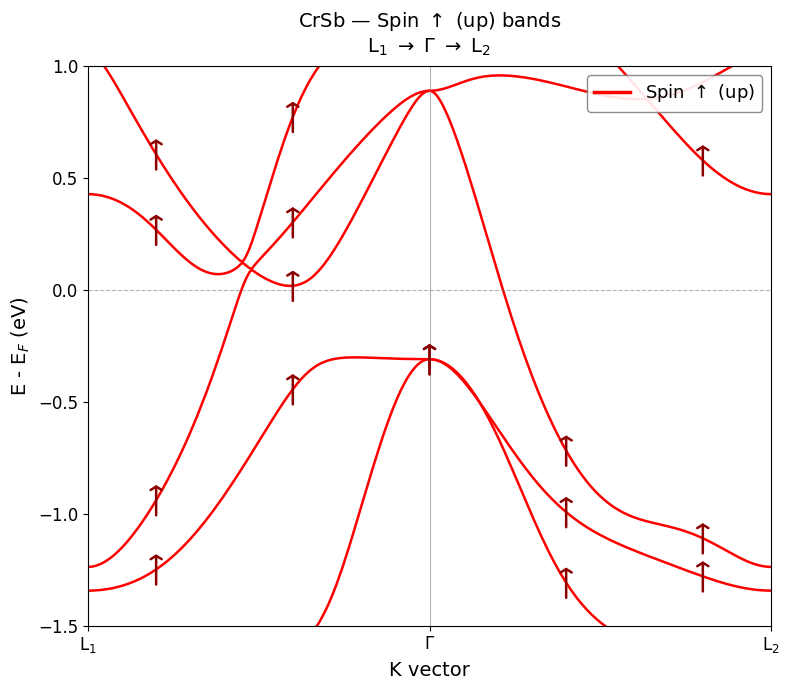

In [9]:
# Spin-Up Plots

fig1, ax1 = plt.subplots(figsize=(8, 7))
for kv, ev in vis_up:
    ax1.plot(kv, ev, color=COLOR_UP, lw=1.8, solid_capstyle='round')
    place_spin_arrows(ax1, kv, ev, direction='up',
                      color=COLOR_ARROW_UP, n_arrows=N_ARROWS_SINGLE)
setup_pyprocar_ax(ax1)
ax1.set_title(
    r'CrSb — Spin $\uparrow$ (up) bands' '\n'
    r'L$_1$ $\rightarrow$ $\Gamma$ $\rightarrow$ L$_2$',
    fontsize=14, pad=10)
up_handle = mlines.Line2D([], [], color=COLOR_UP, lw=2.5,
                           label=r'Spin $\uparrow$ (up)')
ax1.legend(handles=[up_handle], loc='upper right', fontsize=13,
           framealpha=0.9, edgecolor='gray')
fig1.tight_layout()
fig1.savefig('CrSb_bands_spin_up_arrows.png', dpi=DPI, bbox_inches='tight')
plt.show()

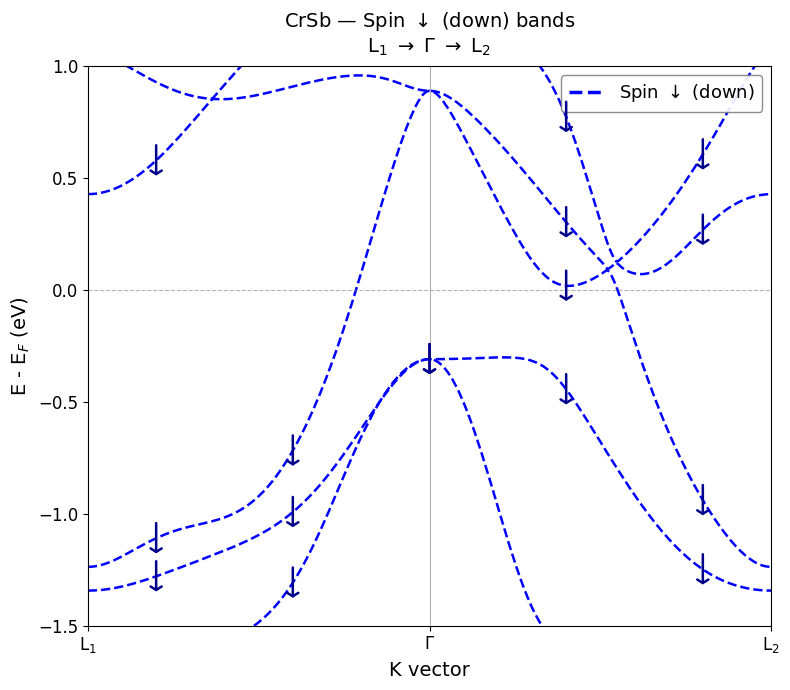

In [10]:
# Spin-Down Plot

fig2, ax2 = plt.subplots(figsize=(8, 7))
for kv, ev in vis_dn:
    ax2.plot(kv, ev, color=COLOR_DN, lw=1.8, ls='--', solid_capstyle='round')
    place_spin_arrows(ax2, kv, ev, direction='down',
                      color=COLOR_ARROW_DN, n_arrows=N_ARROWS_SINGLE)
setup_pyprocar_ax(ax2)
ax2.set_title(
    r'CrSb — Spin $\downarrow$ (down) bands' '\n'
    r'L$_1$ $\rightarrow$ $\Gamma$ $\rightarrow$ L$_2$',
    fontsize=14, pad=10)
dn_handle = mlines.Line2D([], [], color=COLOR_DN, lw=2.5, ls='--',
                           label=r'Spin $\downarrow$ (down)')
ax2.legend(handles=[dn_handle], loc='upper right', fontsize=13,
           framealpha=0.9, edgecolor='gray')
fig2.tight_layout()
fig2.savefig('CrSb_bands_spin_dn_arrows.png', dpi=DPI, bbox_inches='tight')
plt.show()

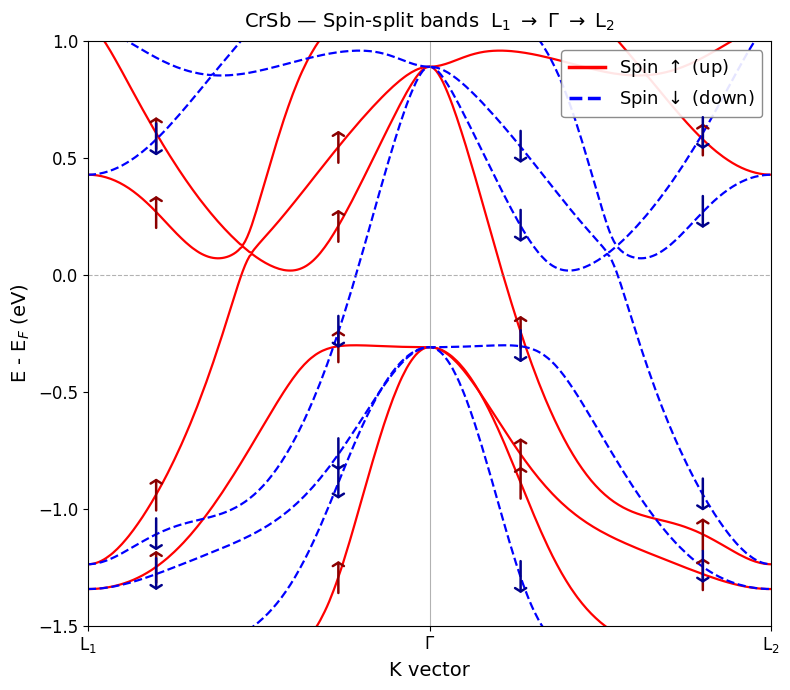

All 3 plots generated!


In [11]:
# Combined Plot

fig3, ax3 = plt.subplots(figsize=(8, 7))
for kv, ev in vis_up:
    ax3.plot(kv, ev, color=COLOR_UP, lw=1.6, solid_capstyle='round')
    place_spin_arrows(ax3, kv, ev, direction='up',
                      color=COLOR_ARROW_UP, n_arrows=N_ARROWS_COMBINED)
for kv, ev in vis_dn:
    ax3.plot(kv, ev, color=COLOR_DN, lw=1.6, ls='--', solid_capstyle='round')
    place_spin_arrows(ax3, kv, ev, direction='down',
                      color=COLOR_ARROW_DN, n_arrows=N_ARROWS_COMBINED)
setup_pyprocar_ax(ax3)
ax3.set_title(
    r'CrSb — Spin-split bands  L$_1$ $\rightarrow$ $\Gamma$ $\rightarrow$ L$_2$',
    fontsize=14, pad=10)
up_h = mlines.Line2D([], [], color=COLOR_UP, lw=2.5,
                      label=r'Spin $\uparrow$ (up)')
dn_h = mlines.Line2D([], [], color=COLOR_DN, lw=2.5, ls='--',
                      label=r'Spin $\downarrow$ (down)')
ax3.legend(handles=[up_h, dn_h], loc='upper right', fontsize=13,
           framealpha=0.9, edgecolor='gray')
fig3.tight_layout()
fig3.savefig('CrSb_bands_combined_arrows.png', dpi=DPI, bbox_inches='tight')
plt.show()
print('All 3 plots generated!')